# Spike-Timing Dependent Plasticity

## Motivation

Previous notebooks treated synaptic strength either as fixed or as temporarily changing due to short-term synaptic dynamics. Spike-timing dependent plasticity (STDP) introduces a different idea: synaptic weights can change depending on the relative timing of presynaptic and postsynaptic spikes.

This notebook implements a simplified phenomenological STDP rule to study how spike timing can shape synaptic weight changes over repeated pairings.

## Synaptic Plasticity and Learning

Synaptic plasticity refers to activity-dependent changes in synaptic strength. In computational models, plasticity rules provide a way for connections between neurons to change over time.

In this notebook, synaptic weight is represented as a scalar variable $w$. The goal is not to model all biological mechanisms of plasticity, but to understand how timing-based update rules can modify synaptic strength.

## Temporal Order of Spikes

STDP depends on the relative timing between a presynaptic spike and a postsynaptic spike.

We define:

$$
\Delta t = t_{post} - t_{pre}
$$

where:

- $t_{pre}$ is the presynaptic spike time,
- $t_{post}$ is the postsynaptic spike time.

If $\Delta t > 0$, the presynaptic spike occurs before the postsynaptic spike. If $\Delta t < 0$, the postsynaptic spike occurs before the presynaptic spike.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
t_pre = 50.0
t_post = 60.0

delta_t = t_post - t_pre
print(f"Delta t = {delta_t} ms")

Delta t = 10.0 ms


## STDP Learning Rule

A common simplified STDP rule uses exponential functions to determine the weight update:

For $\Delta t > 0$:

$$
\Delta w = A_+ \cdot e^{-\Delta t / \tau_+}
$$

For $\Delta t < 0$:

$$
\Delta w = -A_- \cdot e^{\Delta t / \tau_-}
$$

This captures the basic idea that pre-before-post timing tends to increase synaptic weight, while post-before-pre timing tends to decrease it.

In [2]:
A_plus = 0.01
A_minus = 0.012
tau_plus = 20.0
tau_minus = 20.0


def stdp_update(delta_t, A_plus=0.01, A_minus=0.012, tau_plus=20.0, tau_minus=20.0):
    """
    Compute a simplified STDP weight update from spike timing difference.

    Parameters
    ----------
    delta_t : float or np.ndarray
        Spike timing difference defined as t_post - t_pre.
    A_plus : float
        Maximum potentiation amplitude.
    A_minus : float
        Maximum depression amplitude.
    tau_plus : float
        Potentiation time constant.
    tau_minus : float
        Depression time constant.

    Returns
    -------
    delta_w : float or np.ndarray
        Synaptic weight change.
    """
    delta_t_array = np.asarray(delta_t)
    delta_w = np.zeros_like(delta_t_array, dtype=float)

    ltp_mask = delta_t_array > 0
    ltd_mask = delta_t_array < 0

    delta_w[ltp_mask] = A_plus * np.exp(-delta_t_array[ltp_mask] / tau_plus)
    delta_w[ltd_mask] = -A_minus * np.exp(delta_t_array[ltd_mask] / tau_minus)

    if np.isscalar(delta_t):
        return float(delta_w)
    return delta_w

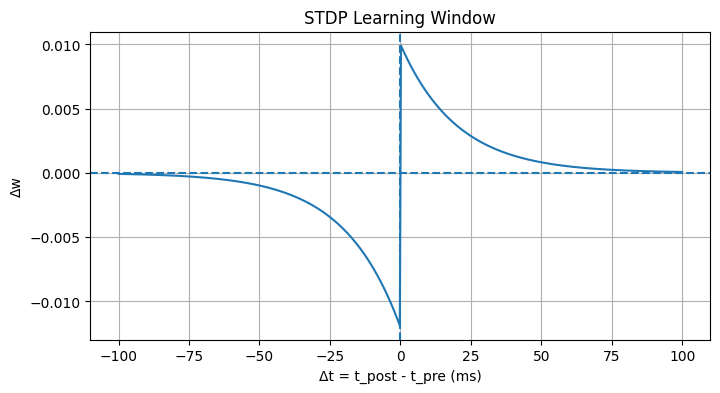

In [3]:
delta_t_values = np.linspace(-100, 100, 500)
delta_w_values = stdp_update(
    delta_t_values,
    A_plus=A_plus,
    A_minus=A_minus,
    tau_plus=tau_plus,
    tau_minus=tau_minus
)

plt.figure(figsize=(8, 4))
plt.plot(delta_t_values, delta_w_values)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Δt = t_post - t_pre (ms)")
plt.ylabel("Δw")
plt.title("STDP Learning Window")
plt.grid(True)
plt.show()

## Long-Term Potentiation and Depression

In this simplified rule, positive weight change corresponds to long-term potentiation (LTP), while negative weight change corresponds to long-term depression (LTD).

The largest changes occur when pre- and postsynaptic spikes are close together in time. As the timing difference becomes larger, the magnitude of the weight update decreases.

## Weight Evolution Over Repeated Spike Pairings

We can now simulate how a synaptic weight changes when the same spike timing relationship is repeated many times.

In [4]:
initial_weight = 0.5
n_pairings = 100
fixed_delta_t = 10.0

weights = np.zeros(n_pairings + 1)
weights[0] = initial_weight

for pairing in range(1, n_pairings + 1):
    delta_w = stdp_update(fixed_delta_t, A_plus=A_plus, A_minus=A_minus, tau_plus=tau_plus, tau_minus=tau_minus)
    weights[pairing] = weights[pairing - 1] + delta_w

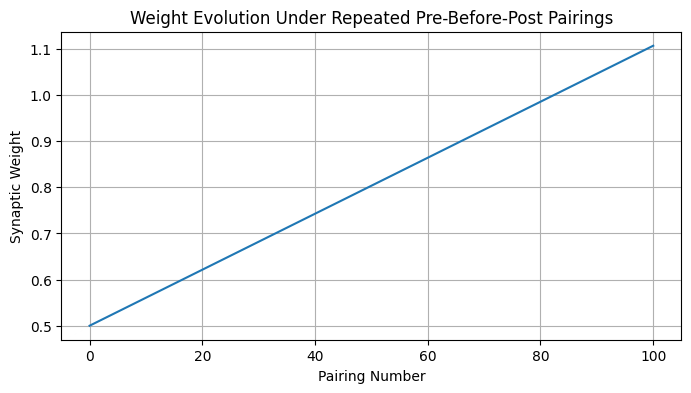

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(weights)
plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Weight Evolution Under Repeated Pre-Before-Post Pairings")
plt.grid(True)
plt.show()

With repeated pre-before-post pairings, the synaptic weight increases gradually. This illustrates how a local timing-based rule can accumulate into longer-term changes in synaptic strength.

In this first implementation, weights are intentionally left unbounded so that the raw effect of the STDP rule is visible. In more realistic simulations, synaptic weights should usually be constrained using bounds or homeostatic mechanisms.

## Effect of Spike Timing Difference (Δt)

Different spike timing differences produce different weight trajectories. Timing relationships closer to zero produce stronger updates, while larger timing gaps produce weaker changes.

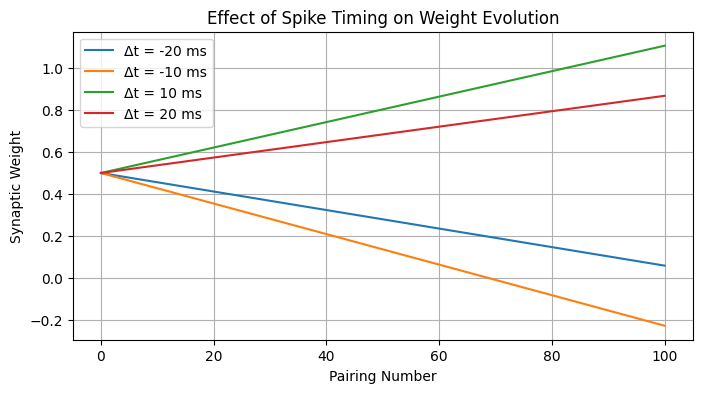

In [6]:
fixed_delta_t_values = [-20, -10, 10, 20]

plt.figure(figsize=(8, 4))

for fixed_dt in fixed_delta_t_values:
    weights_timing = np.zeros(n_pairings + 1)
    weights_timing[0] = initial_weight

    for pairing in range(1, n_pairings + 1):
        delta_w = stdp_update(
            fixed_dt,
            A_plus=A_plus,
            A_minus=A_minus,
            tau_plus=tau_plus,
            tau_minus=tau_minus
        )
        weights_timing[pairing] = weights_timing[pairing - 1] + delta_w

    plt.plot(weights_timing, label=f"Δt = {fixed_dt} ms")

plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Effect of Spike Timing on Weight Evolution")
plt.grid(True)
plt.legend()
plt.show()

The sign and magnitude of $\Delta t$ determine whether synaptic weight increases or decreases. This makes STDP a timing-sensitive learning rule rather than a simple activity counter.

Because this version has no weight bounds, some trajectories may become biologically unrealistic; this is useful for illustrating the raw rule, but it should not be treated as a complete model of synaptic learning.

## Limitations

This notebook implements a simplified phenomenological STDP rule. It does not model the detailed molecular mechanisms underlying synaptic plasticity, such as NMDA receptor activation, calcium signaling, kinase/phosphatase cascades, or structural synaptic changes.

The model also lacks weight bounds, homeostatic regulation, stochastic spike generation, and network-level feedback. Without these mechanisms, repeated updates can drive weights unrealistically high or low.

Therefore, this notebook should be interpreted as a conceptual timing-based plasticity model, not a complete biological model of learning.

## Connection to Larger Learning Models

STDP provides a bridge between spike timing and adaptive synaptic weights. In larger models, this rule can be combined with feedforward networks, noisy inputs, modulatory signals, or neuron–glia-inspired mechanisms.

The next step is to examine how timing-sensitive learning behaves when embedded in small network simulations and how additional modulation can shape plasticity.